### 경로 설정
실행 환경에 맞게 수정

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = '/content/drive/MyDrive/Colab Notebooks/2025-2 빅데이터알고리즘'
ratings

# (1) 사용자 클러스터링 (취향이 비슷한 유저 그룹 찾기)

/tmp/ipython-input-1095113594.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_stats['std_rating'].fillna(0, inplace=True)


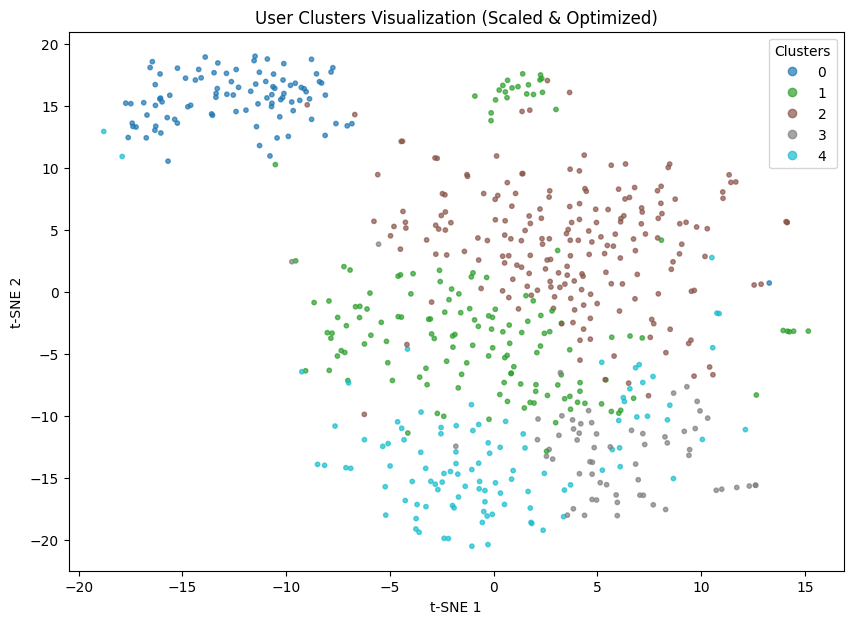

Cluster Sizes:
cluster
2    197
1    150
4    106
0     96
3     61
Name: count, dtype: int64
         avg_rating    Action     Drama  Thriller  std_rating
cluster                                                      
0          3.564252  0.345867  0.421086  0.369865    0.904695
1          3.613022  0.415629  0.356942  0.312903    0.948530
2          3.566990  0.207331  0.445960  0.202758    0.976687
3          3.914870  0.449176  0.375059  0.238145    0.788400
4          3.823398  0.298996  0.527638  0.313854    0.904816


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. 기초 통계 (Rating Stats)
# std_rating의 결측치는 0으로 채움 (평가 1개인 경우)
user_stats = ratings.groupby('userId')['rating'].agg(['mean', 'std']).reset_index()
user_stats.columns = ['userId', 'avg_rating', 'std_rating']
user_stats['std_rating'].fillna(0, inplace=True)

# 2. 장르 선호도 (Genre Ratio)
# 유저가 본 영화 중 해당 장르가 차지하는 비율 (0~1 사이 값)
genre_dummies = movies['genres'].str.get_dummies(sep='|')
movie_genre = pd.concat([movies[['movieId']], genre_dummies], axis=1)

merged = ratings.merge(movie_genre, on='movieId')
# rating 컬럼 제외하고 장르 컬럼만 선택하여 평균
genre_cols = genre_dummies.columns
user_genre_pref = merged.groupby('userId')[genre_cols].mean().reset_index()

# 3. 태그 TF-IDF (Tag Content)
# [최적화] 영화별로 태그를 먼저 합침 (Document = Movie)
valid_tags = tags.dropna(subset=['tag'])
movie_tags_str = valid_tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

tfidf = TfidfVectorizer(max_features=300, stop_words='english') # 불용어 제거 추가
movie_tfidf_matrix = tfidf.fit_transform(movie_tags_str['tag'])

# 영화별 TF-IDF DataFrame 생성
movie_tag_df = pd.DataFrame(movie_tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
movie_tag_df['movieId'] = movie_tags_str['movieId'].values

# 유저가 본 영화들의 태그 벡터 평균 계산
# movieId, rating 등 불필요한 컬럼이 섞이지 않도록 merge 후 컬럼 필터링 주의
user_tag_merged = ratings[['userId', 'movieId']].merge(movie_tag_df, on='movieId')
user_tag_pref = user_tag_merged.drop(columns=['movieId']).groupby('userId').mean().reset_index()

# 4. 벡터 병합
user_vector = user_stats.merge(user_genre_pref, on='userId', how='left')
user_vector = user_vector.merge(user_tag_pref, on='userId', how='left')
user_vector.fillna(0, inplace=True) # 태그/장르 정보 없는 유저 0 처리

# 5. 스케일링 (Scaling)
# userId 제외하고 값만 추출
X = user_vector.drop(columns=['userId']).values

# Feature 간 스케일 차이를 맞춤
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. 차원 축소 및 클러스터링
# 고차원 → SVD (30차원)
svd = TruncatedSVD(n_components=30, random_state=42)
user_lowdim = svd.fit_transform(X_scaled)

# KMeans 클러스터링
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(user_lowdim)
user_vector['cluster'] = clusters

# 7. 시각화 (t-SNE)
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
emb = tsne.fit_transform(user_lowdim)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(emb[:,0], emb[:,1], c=user_vector['cluster'], s=10, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("User Clusters Visualization (Scaled & Optimized)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

print("Cluster Sizes:")
print(user_vector['cluster'].value_counts())

# 클러스터별 평균 특성 비교
cluster_analysis = user_vector.groupby('cluster')[['avg_rating', 'Action', 'Drama', 'Thriller', 'std_rating']].mean()
print(cluster_analysis)

평점 정규화(Normalization)의 필요성 입증:
Cluster 3(평균 3.91) 유저와 Cluster 0(평균 3.56) 유저가 똑같이 4점을 줬을 때, 그 의미는 다름

Cluster 0의 4점은 "정말 명작"이라는 뜻이고, Cluster 3의 4점은 "볼만했다"는 뜻일 수 있음
→ Mean-Centering(User Bias 제거) 실험이 왜 필수적인지 보여주는 근거

# (2) 장르 조합(멀티 장르)의 패턴 분석

/tmp/ipython-input-3754159586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=genre_freq.index, x=genre_freq.values, palette='viridis')


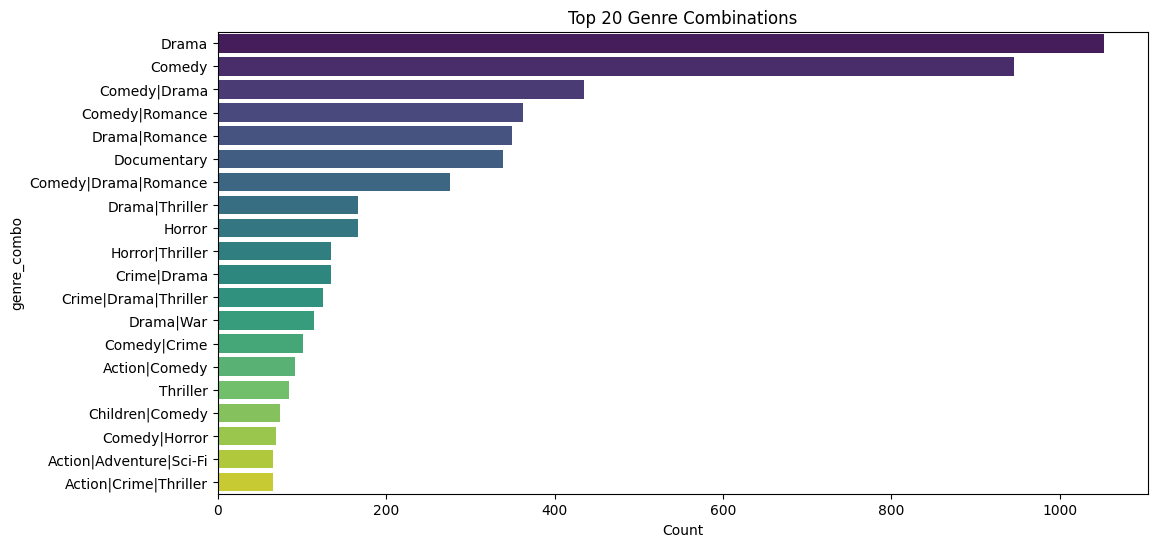

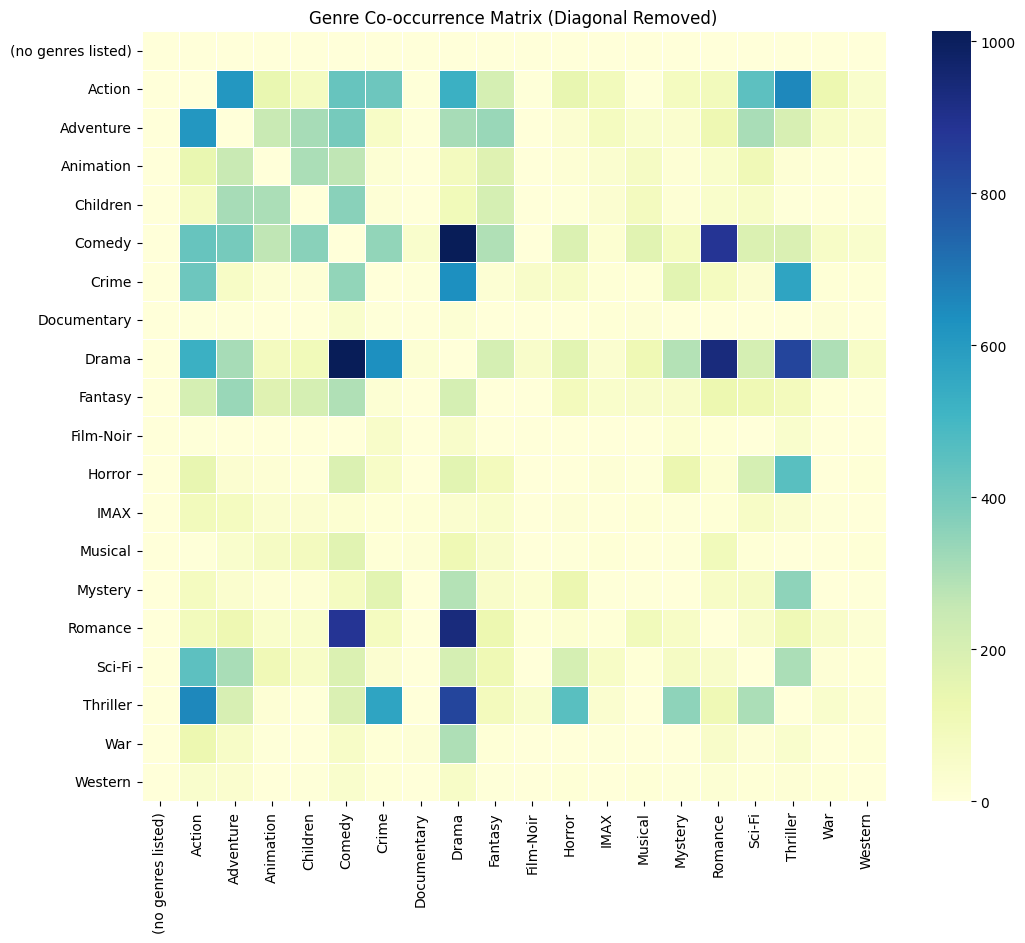

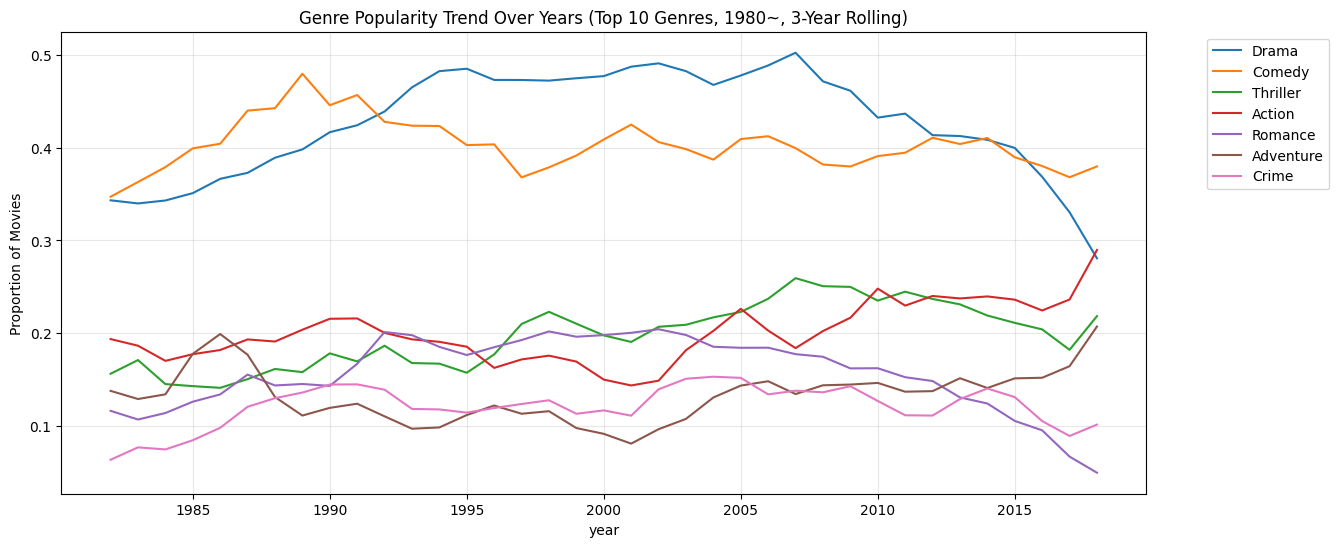

In [ ]:
# 1. 장르 조합 빈도
movies['genre_combo'] = movies['genres']
genre_freq = movies['genre_combo'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(y=genre_freq.index, x=genre_freq.values, palette='viridis')
plt.title("Top 20 Genre Combinations")
plt.xlabel("Count")
plt.show()


# 2. 장르 Co-occurrence Matrix
genre_matrix = genre_dummies.T.dot(genre_dummies)

# 대각선(자기 자신)은 값이 너무 커서 다른 관계를 가리므로 0으로 처리
np.fill_diagonal(genre_matrix.values, 0)

plt.figure(figsize=(12, 10))
sns.heatmap(genre_matrix, cmap='YlGnBu', linewidths=.5)
plt.title("Genre Co-occurrence Matrix (Diagonal Removed)")
plt.show()

# 3. 연도별 장르 트렌드
# 연도 추출 (결측치 제거)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies = movies.dropna(subset=['year']) # 연도 없는 데이터 제거

# 연도별 장르 비율 계산
# concat을 사용하여 인덱스 불일치 방지
genre_year_df = pd.concat([movies[['year']], genre_dummies], axis=1)
year_trend = genre_year_df.groupby('year').mean()

# 여기서는 1980년 이후 데이터만 확인
year_trend = year_trend[year_trend.index >= 1980]

# 상위 7개 인기 장르만 선정
top_genres = genre_dummies.sum().sort_values(ascending=False).head(7).index
year_trend_top = year_trend[top_genres]

# 3년 윈도우 적용
year_trend_smooth = year_trend_top.rolling(window=3).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(data=year_trend_smooth, dashes=False)
plt.title("Genre Popularity Trend Over Years (Top 10 Genres, 1980~, 3-Year Rolling)")
plt.ylabel("Proportion of Movies")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

- 연도별 장르를 점수 평균으로 내기
-

# (3) 태그를 활용한 내용 기반(content-based) 추천용 피처 엔지니어링

Matrix Shape: (1572, 252)


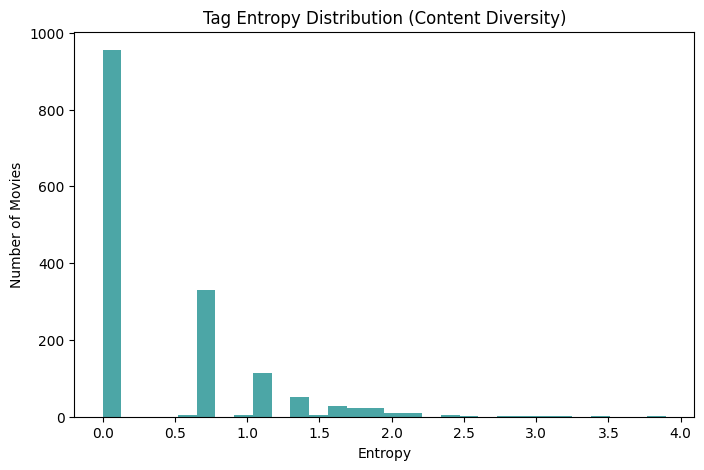

Similarity Matrix Calculated: (1572, 1572)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

# 1. 영화별로 태그 합치기
tag_data = tags.dropna(subset=['tag'])
tag_data['tag'] = tag_data['tag'].astype(str)
movie_tags = tag_data.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()

# 2. TF-IDF Vectorization
# min_df=5: 최소 5개 영화에 등장한 태그만 사용 (노이즈 제거)
tfidf = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english')
movie_tag_tfidf = tfidf.fit_transform(movie_tags['tag'])

print(f"Matrix Shape: {movie_tag_tfidf.shape}")

# 3. 태그 다양성 지표 (Entropy)
# Sparse Matrix 상태에서 바로 계산하여 메모리 절약
def sparse_entropy(matrix):
    # 각 행(영화)의 합이 1이 되도록 정규화
    # TF-IDF 값 자체를 확률로 간주
    row_sums = np.array(matrix.sum(axis=1))

    # 0으로 나누기 방지
    row_sums[row_sums == 0] = 1
    probs = matrix / row_sums

    # Entropy 계산: -sum(p * log(p))
    # sparse matrix 연산 효율을 위해 data 속성 직접 조작
    probs.data = probs.data * np.log(probs.data)
    return -np.array(probs.sum(axis=1)).flatten()

tag_entropy = sparse_entropy(movie_tag_tfidf)

plt.figure(figsize=(8, 5))
plt.hist(tag_entropy, bins=30, color='teal', alpha=0.7)
plt.title("Tag Entropy Distribution (Content Diversity)")
plt.xlabel("Entropy")
plt.ylabel("Number of Movies")
plt.show()

# 4. 태그 기반 영화 유사도 (Cosine Similarity)
sim_tag = cosine_similarity(movie_tag_tfidf)
print("Similarity Matrix Calculated:", sim_tag.shape)

# (4) 평점 시계열을 활용한 유저/영화의 트렌드 분석

In [ ]:
# 1. Timestamp 변환
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
# 시각화를 위해 Period 대신 datetime의 1일자로 맞춤
ratings['year_month'] = ratings['datetime'].dt.to_period('M').dt.to_timestamp()

# 2. 유저 활동량 변화
# 월별 전체 평점 개수 / 월별 활성 유저 수 = 인당 평균 활동량
monthly_stats = ratings.groupby('year_month').agg(
    total_ratings=('rating', 'count'),
    active_users=('userId', 'nunique')
).reset_index()

monthly_stats['ratings_per_user'] = monthly_stats['total_ratings'] / monthly_stats['active_users']

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_stats, x='year_month', y='ratings_per_user', color='coral')
plt.title("Average Ratings per User Over Time (Activity Intensity)")
plt.ylabel("Avg Ratings count per User")
plt.xlabel("Year-Month")
plt.grid(True, alpha=0.3)
plt.show()

# 3. 영화 평점 시계열 (개별 영화 트렌드)
# 데이터 집계
movie_trend = ratings.groupby(['movieId', 'year_month'])['rating'].mean().reset_index()

# 보고 싶은 영화 ID 지정 (예: 토이스토리(1), 스타워즈(260), 펄프픽션(296))
target_movies = [1, 260, 296]
sample = movie_trend[movie_trend['movieId'].isin(target_movies)].copy()

# hue 구분을 위해 문자열로 변환
sample['movieId_str'] = sample['movieId'].astype(str)

# 이동 평균(Rolling)으로 노이즈 제거 (Window=6개월)
sample['rating_smooth'] = sample.groupby('movieId_str')['rating'].transform(lambda x: x.rolling(window=6, min_periods=1).mean())

plt.figure(figsize=(12, 5))
sns.lineplot(data=sample, x='year_month', y='rating_smooth', hue='movieId_str', palette='tab10', linewidth=2)
plt.title("Movie Rating Trends Over Time (6-Month Moving Average)")
plt.ylim(2.5, 5.0) # 평점 범위 고정
plt.legend(title="Movie ID")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'pd' is not defined

연도별 -> 월별 raitng으로 확장
- rating 추세 보기 (예전에는 짜게 줬는데 지금은 후하게 줌)

# (5) 리메이크 영화 확인

폰트 설정 (skip 가능)
- 이 셀을 실행 후 세션 다시 시작
- 현재 노트북의 1,2번째 셀 실행

In [ ]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt

# 2. 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 3. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.8 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and direc

총 영화 수: 9742
제목이 동일한(리메이크/중복) 영화 수: 536

[리메이크 예시 데이터]
      movieId                   clean_title    year  \
905      1203                  12 Angry Men  1957.0   
7332    77846                  12 Angry Men  1997.0   
9051   141844                     12 Chairs  1971.0   
9046   141816                     12 Chairs  1976.0   
6863    62383  20,000 Leagues Under the Sea  1916.0   
777      1019  20,000 Leagues Under the Sea  1954.0   
3791     5300                  3:10 to Yuma  1957.0   
6557    54997                  3:10 to Yuma  2007.0   
3116     4191                         Alfie  1966.0   
5364     8948                         Alfie  2004.0   

                                       genres  
905                                     Drama  
7332                              Crime|Drama  
9051                         Adventure|Comedy  
9046                         Adventure|Comedy  
6863                  Action|Adventure|Sci-Fi  
777                    Adventure|Drama|Sci-Fi  
379

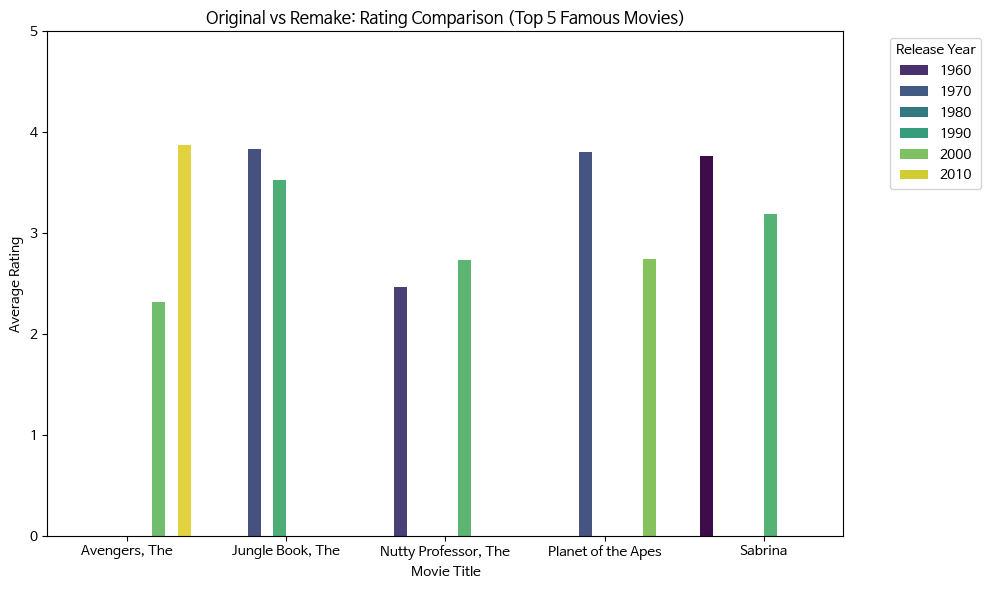


[장르 기반 리메이크 분석 결론]
1. 장르 100% 일치 리메이크 수: 36
2. 장르 변경된 리메이크 수 (유사도 >= 0.5): 108
3. 동명이인 의심 영화 수 (유사도 < 0.3): 65

[분석 상세: 장르 변경 사례 (상위 5개)]
                          Title                                  Genre_1  \
0                  12 Angry Men                                    Drama   
2  20,000 Leagues Under the Sea                  Action|Adventure|Sci-Fi   
3                  3:10 to Yuma  Action|Adventure|Drama|Thriller|Western   
6           Alice in Wonderland               Adventure|Children|Fantasy   
8        Amityville Horror, The            Drama|Horror|Mystery|Thriller   

                                        Genre_2  Similarity_Score  
0                                   Crime|Drama               0.5  
2                        Adventure|Drama|Sci-Fi               0.5  
3                    Action|Crime|Drama|Western               0.5  
6  Adventure|Animation|Children|Fantasy|Musical               0.6  
8                               Horror|Thriller               0.

/tmp/ipython-input-4225909263.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  remake_comparison = dup_titles.groupby('clean_title').apply(analyze_genre_similarity).reset_index(drop=True)


In [ ]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
import re

# 운영체제별 폰트 설정
system_name = platform.system()

if system_name == 'Windows':
    # 윈도우
    rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    # 맥 (Mac)
    rc('font', family='AppleGothic')
elif system_name == 'Linux':
    # 코랩 / 리눅스 (나눔글꼴 설치 필요)
    rc('font', family='NanumBarunGothic')
else:
    print("Unknown System")

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
movies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2025-2 빅데이터알고리즘/movies.csv')
ratings = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2025-2 빅데이터알고리즘/ratings.csv')

# 1. 데이터 전처리: 제목과 연도 분리
def extract_year_title(text):
    # 텍스트가 문자열이 아닌 경우 처리
    if not isinstance(text, str):
        return str(text), np.nan

    # 괄호 안의 4자리 숫자 추출 (예: (1995))
    match = re.search(r'^(.*)\s\((\d{4})\)$', text)
    if match:
        title = match.group(1).strip()
        year = int(match.group(2))
        return title, year
    return text, np.nan

# apply로 새로운 컬럼 생성
movies[['clean_title', 'year']] = movies['title'].apply(
    lambda x: pd.Series(extract_year_title(x))
)

# 2. 리메이크 의심작 찾기 (제목은 같고 연도는 다른 것)
# clean_title이 중복되는 데이터 찾기
dup_titles = movies[movies.duplicated(subset=['clean_title'], keep=False)].sort_values(by=['clean_title', 'year'])

print(f"총 영화 수: {len(movies)}")
print(f"제목이 동일한(리메이크/중복) 영화 수: {len(dup_titles)}")
print("\n[리메이크 예시 데이터]")
print(dup_titles[['movieId', 'clean_title', 'year', 'genres']].head(10))

# 3. 원작 vs 리메이크 평점 비교 분석
# 평점 데이터와 결합
movie_ratings = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
remake_analysis = dup_titles.merge(movie_ratings, on='movieId')

# 리뷰가 너무 적은 영화는 제외 (노이즈 제거, 10개 미만)
remake_analysis = remake_analysis[remake_analysis['count'] >= 10]

# 같은 제목끼리 그룹화
remake_groups = remake_analysis.groupby('clean_title').filter(lambda x: len(x) >= 2)

# 시각화를 위해 리뷰 수가 많은 상위 5개 리메이크작 선정
top_remakes = remake_groups.groupby('clean_title')['count'].sum().sort_values(ascending=False).head(5).index
plot_data = remake_groups[remake_groups['clean_title'].isin(top_remakes)]

# 4. 시각화: 원작 vs 리메이크 평점 비교
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='clean_title', y='mean', hue='year', palette='viridis')
plt.title("Original vs Remake: Rating Comparison (Top 5 Famous Movies)")
plt.ylabel("Average Rating")
plt.xlabel("Movie Title")
plt.legend(title="Release Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

# 5. 장르 유사도 정밀 분석 (자카드 유사도 적용)
def analyze_genre_similarity(group):
    # 데이터가 2개 미만이면 비교 불가
    if len(group) < 2:
        return None

    genres = group['genres'].tolist()
    years = group['year'].tolist()

    # 첫 번째 영화와 두 번째 영화 비교
    set1 = set(genres[0].split('|'))
    set2 = set(genres[1].split('|'))

    # 교집합과 합집합 계산
    intersection = set1.intersection(set2)
    union = set1.union(set2)

    # 자카드 유사도 계산 (0~1)
    score = len(intersection) / len(union) if len(union) > 0 else 0

    return pd.Series({
        'Title': group['clean_title'].iloc[0],
        'Year_1': years[0],
        'Year_2': years[1],
        'Genre_1': genres[0],
        'Genre_2': genres[1],
        'Is_Exact_Match': set1 == set2,      # 완전 일치 여부
        'Similarity_Score': round(score, 2)  # 유사도 점수
    })

# 그룹별로 적용하여 분석 프레임 생성
remake_comparison = dup_titles.groupby('clean_title').apply(analyze_genre_similarity).reset_index(drop=True)

# 6. 분석 결과 분류 및 출력

# Case A: 장르 100% 일치 (확실한 리메이크)
exact_remakes = remake_comparison[remake_comparison['Is_Exact_Match'] == True]

# Case B: 장르가 조금 변경됨 (유사도 0.5 이상 1.0 미만)
changed_remakes = remake_comparison[
    (remake_comparison['Similarity_Score'] >= 0.5) &
    (remake_comparison['Is_Exact_Match'] == False)
]

# Case C: 이름만 같고 다른 영화 (유사도 0.3 미만, 동명이인)
different_movies = remake_comparison[remake_comparison['Similarity_Score'] < 0.3]

print("\n[장르 기반 리메이크 분석 결론]")
print(f"1. 장르 100% 일치 리메이크 수: {len(exact_remakes)}")
print(f"2. 장르 변경된 리메이크 수 (유사도 >= 0.5): {len(changed_remakes)}")
print(f"3. 동명이인 의심 영화 수 (유사도 < 0.3): {len(different_movies)}")

print("\n[분석 상세: 장르 변경 사례 (상위 5개)]")
print(changed_remakes[['Title', 'Genre_1', 'Genre_2', 'Similarity_Score']].head())

장르 100% 일치 리메이크 수: 36
-> 나중에 어떻게 쓸지 확인


[전처리 아이디어] 이 데이터를 어떻게 쓸지

"Frozen (2013)"을 본 사람에게 "Frozen (2010)"은 추천하면 안 될 수도 있음 (장르가 다르면)

"Aladdin (1992)"을 본 사람에게 "Aladdin (2019)"를 추천해야 함 (같은 IP)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 데이터 전제: ratings['timestamp']가 존재해야 함
# timestamp가 Unix time이라면 datetime으로 변환
if 'timestamp' in ratings.columns:
    ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
    ratings['year'] = ratings['date'].dt.year

# ---------------------------------------------------------
# 1. [Time Decay] 연도별 평점 활동 추이
# -> "최근 데이터가 이만큼 많으니/적으니 시간 가중치가 필요하다/불필요하다" 논리
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
yearly_counts = ratings['year'].value_counts().sort_index()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='green')
plt.title('연도별 평점 개수 추이 (Time Decay 근거)')
plt.xlabel('연도')
plt.ylabel('평점 수')
plt.grid(True)
plt.show()

print("Insight: 데이터가 특정 시기에 몰려있거나, 꾸준히 쌓였다면 최신성을 반영하는 Time Decay 실험이 유효함.")

# ---------------------------------------------------------
# 2. [Genre Bias] 장르별 평점 분포 (Boxplot)
# -> "장르마다 기본 점수 베이스가 다르니, 이걸 맞춰줘야(Normalize) 한다" 논리
# ---------------------------------------------------------
# 영화별로 장르를 쪼개서 평점과 매칭 (데이터가 커질 수 있으니 주의)
# 간단하게 확인하기 위해, 각 영화의 'Main Genre'(첫번째 장르)만 추출해서 비교
movies['main_genre'] = movies['genres'].apply(lambda x: x.split('|')[0])
merged_df = pd.merge(ratings, movies[['movieId', 'main_genre']], on='movieId')

plt.figure(figsize=(14, 6))
# 평점 평균 기준 정렬
order = merged_df.groupby('main_genre')['rating'].mean().sort_values(ascending=False).index
sns.boxplot(x='main_genre', y='rating', data=merged_df, order=order, palette="coolwarm")
plt.title('장르별 평점 분포 차이 (Genre Bias 확인)')
plt.xticks(rotation=45)
plt.show()

print("Insight: 특정 장르(예: Documentary)가 Drama나 Horror보다 중앙값이 높다면, '장르 편향 제거' 전처리가 유효함.")

# ---------------------------------------------------------
# 3. [Scale Usage] 평점 값(Rating Value) 사용 패턴
# -> "0.5점 단위를 잘 안 쓴다면, 굳이 복잡하게 0.5를 맞출 필요가 있을까?" 논리
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='rating', data=ratings, palette="pastel")
plt.title('평점 값(Score)별 빈도수 (Rating Granularity)')

# 막대 위에 비율 표시
total = len(ratings)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.1f}%'.format(height/total*100), ha="center")
plt.show()

print("Insight: 만약 .5 점수들의 빈도가 현저히 낮다면, Rounding(반올림) 전처리 실험을 제안 가능.")

NameError: name 'ratings' is not defined